# 03 — YOLO Model Training

Train and fine-tune a YOLO object detection model on the prepared BDD100K dataset.

### Objectives
- Check the training environment and GPU
- Select the YOLO model
- Configure training parameters
- Train the model on BDD100K
- Save the best model weights
- Review training results

### Project Roadmap
**Dataset Exploration → Data Preparation → YOLO Training → Evaluation → Inference → Driving Risk Analysis**



## 1. Environment Setup

In [1]:
# ==============================
# Libraries
# ==============================

from pathlib import Path

import torch

In [2]:
# ==============================
# Hardware Check
# ==============================

# Display the installed PyTorch version
print("PyTorch version :", torch.__version__)

# Check whether CUDA is available
print("CUDA available  :", torch.cuda.is_available())

# Display GPU information if CUDA is available
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU memory      :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )
else:
    print("GPU             : CUDA GPU not detected")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : NVIDIA GeForce GTX 1650
GPU memory      : 4.0 GB


## 2. Model Selection

In [3]:
# ==============================
# Ultralytics
# ==============================

from ultralytics import YOLO

import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Ultralytics version: 8.4.126


In [4]:
# ==============================
# Load Candidate YOLO Models
# ==============================

# Load pretrained candidate models
model_n = YOLO("yolo26n.pt")
model_s = YOLO("yolo26s.pt")

print("YOLO26n loaded successfully.")
print("YOLO26s loaded successfully.")

YOLO26n loaded successfully.
YOLO26s loaded successfully.


In [5]:
# ==============================
# Compare Candidate Models
# ==============================

print("YOLO26n")
model_n.info()

print("\nYOLO26s")
model_s.info()


YOLO26n
YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.2 GFLOPs

YOLO26s
YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 23.1 GFLOPs


(260, 10009784, 0, 23.0793216)

## 3. Training Configuration

### Training Parameters

- **imgsz** → Input image size
- **batch** → Number of images processed simultaneously by the GPU
- **epochs** → Number of times the model sees the entire training dataset
- **device** → GPU device used for training
- **workers** → Number of parallel processes used for loading data

In [6]:
# ==============================
# Training Configuration
# ==============================

MODEL_NAME = "yolo26s.pt"

DATA_YAML = "../data/bdd100k/dataset.yaml"

IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 1

DEVICE = 0
WORKERS = 0

## 4. Trial Training

In [7]:
# ==============================
# Trial Training
# ==============================

# Load the selected pretrained YOLO model
model = YOLO(MODEL_NAME)

# Run a short training test
trial_results = model.train(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    epochs=EPOCHS,
    device=DEVICE,
    workers=WORKERS,
    project="../runs",
    name="yolo26s_trial",
    pretrained=True,
    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.130 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.126  Python-3.12.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/bdd100k/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, m

## 5. Main Training

In [6]:
# ==============================
# Main Training Configuration
# ==============================

MODEL_NAME = "yolo26s.pt"
DATA_YAML = "../data/bdd100k/dataset.yaml"

IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 50

DEVICE = 0
WORKERS = 0

In [ ]:


model = YOLO(MODEL_NAME)

main_results = model.train(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    epochs=EPOCHS,
    device=DEVICE,
    workers=WORKERS,

    amp=False,
    pretrained=True,

    save=True,
    save_period=1,

    patience=10,

    project="../runs",
    name="yolo26s_main"
)

Ultralytics 8.4.126  Python-3.12.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/bdd100k/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_main-2, nbs=

In [1]:
from ultralytics import YOLO

model = YOLO("../runs/runs/yolo26s_main/weights/last.pt")

main_results = model.train(resume=True)

Ultralytics 8.4.126  Python-3.12.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\data\bdd100k\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=..\runs\runs\yolo26s_main\weights\last.pt, momentum=0.937, mosaic=1.0, multi_scale

## 6. Training Results

The YOLO26s model was successfully fine-tuned on the BDD100K dataset for 50 epochs.

### Training Configuration
- Model: YOLO26s
- Dataset: BDD100K
- Training images: 70,000
- Validation images: 10,000
- Image size: 512 × 512
- Batch size: 2
- Epochs: 50
- Device: NVIDIA GeForce GTX 1650
- AMP: Disabled

Training checkpoints and metrics were saved during training.
The best-performing checkpoint will be used for detailed evaluation in the next notebook.

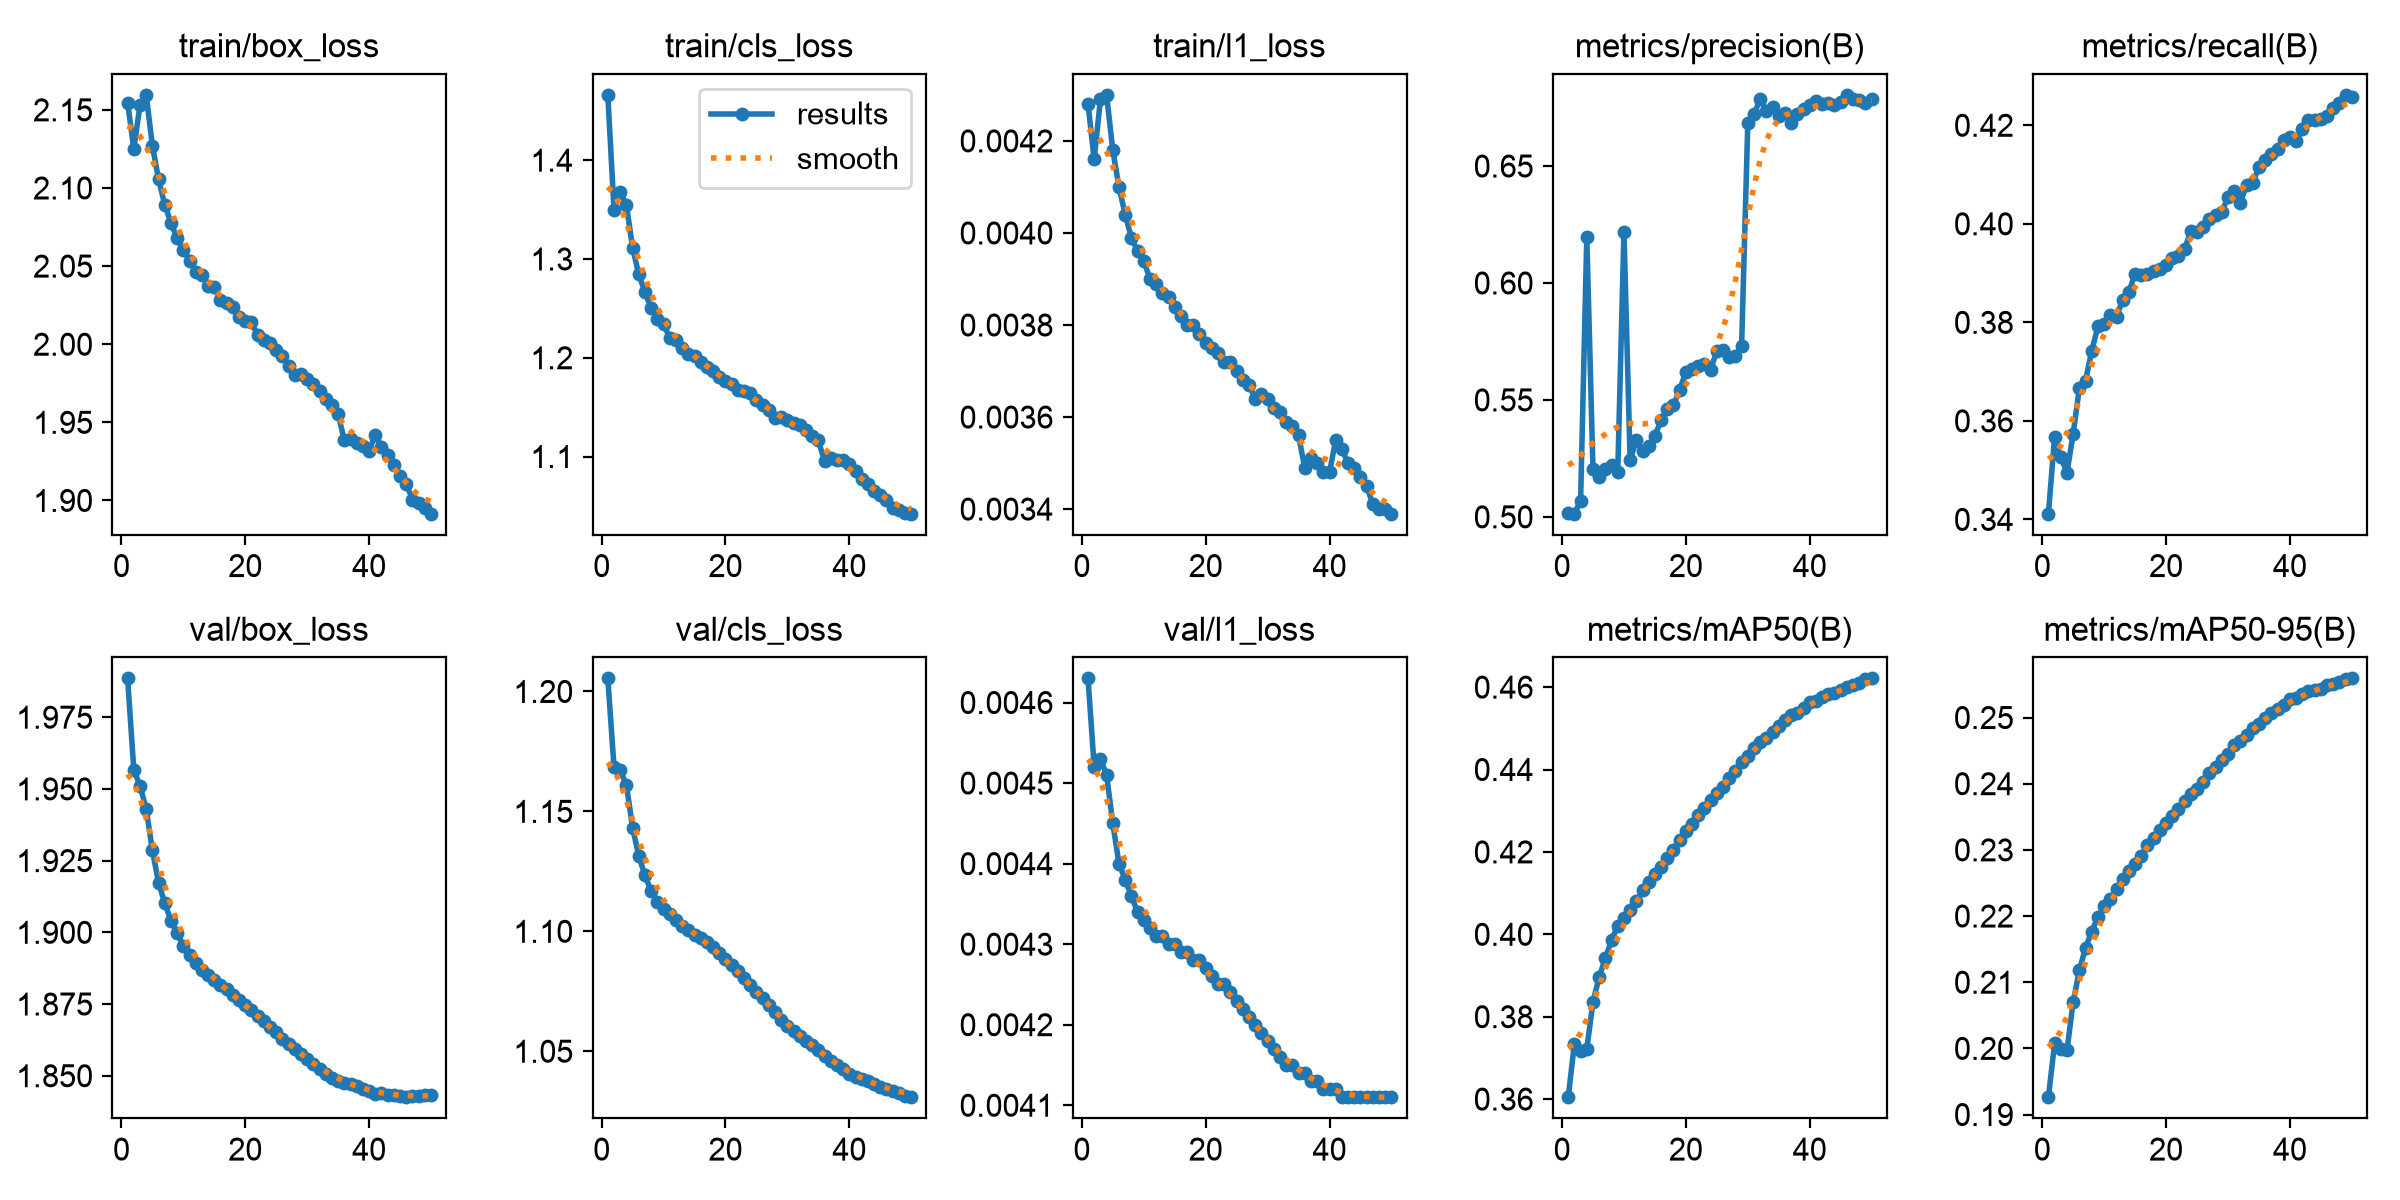

In [2]:
from IPython.display import Image, display

display(Image(filename="../runs/runs/yolo26s_main/results.png"))

## 7. Conclusion

YOLO26s was successfully trained on the BDD100K object detection dataset.

The training pipeline completed all 50 epochs and generated model checkpoints,
training curves, validation predictions, and evaluation metrics.

The best trained model will be used in the next stage for detailed model evaluation,
including Precision, Recall, mAP50, mAP50-95, confusion matrix analysis, and
per-class performance.

### Next Step
**Notebook 04 — YOLO Model Evaluation**